In [ ]:
!unzip Mild_Demented.zip
!unzip Moderate_Demented.zip
!unzip Non_Demented.zip
!unzip Very_Mild_Demented.zip

In [ ]:
!mkdir dataset
!cp -r Non_Demented dataset/Non_Demented #0
!cp -r Mild_Demented dataset/Mild_Demented #1
!cp -r Moderate_Demented dataset/Moderate_Demented #2
!cp -r Very_Mild_Demented dataset/Very_Mild_Demented #3

In [ ]:
!pip install split-folders
import splitfolders
splitfolders.ratio('/content/dataset', output="output", seed=1345, ratio=(.8, 0.1,0.1))

Copying files: 6400 files [00:01, 5447.03 files/s]


In [ ]:
import tensorflow as tf
IMG_HEIGHT = 128
IMG_WIDTH = 128
def preprocess_images(image, label):
    image = tf.cast(image, tf.float32) / 255.0  # Normalizar los píxeles al rango [0, 1]
    image = tf.image.rgb_to_grayscale(image)  # Convertir la imagen a blanco y negro
    return image, label
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "./output/train",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=64,
    label_mode='categorical',  # Asumiendo clasificación categórica, ajustar según sea necesario
    shuffle=True

)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "./output/test",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=64,
    label_mode='categorical',  # Asumiendo clasificación categórica, ajustar según sea necesario
    shuffle=False,  # No es necesario barajar el conjunto de prueba
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "./output/val",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=64,
    label_mode='categorical',  # Asumiendo clasificación categórica, ajustar según sea necesario
    shuffle=True
)

# Obtener las clases del conjunto de entrenamiento antes de aplicar map
classes_train = train_ds.class_names

train_ds = train_ds.map(lambda x, y: (preprocess_images(x, y)))
test_ds = test_ds.map(lambda x, y: (preprocess_images(x, y)))
val_ds = val_ds.map(lambda x, y: (preprocess_images(x, y)))


# Imprimir las clases
print("Clases del conjunto de entrenamiento:", classes_train)

Found 5119 files belonging to 4 classes.
Found 642 files belonging to 4 classes.
Found 639 files belonging to 4 classes.
Clases del conjunto de entrenamiento: ['Mild_Demented', 'Moderate_Demented', 'Non_Demented', 'Very_Mild_Demented']


In [ ]:
import matplotlib.pyplot as plt
# Obtener un lote de imágenes después de la transformación
sample_images, sample_labels = next(iter(train_ds))

# Imprimir los valores de los píxeles de la primera imagen en el lote
print("Valores de píxeles después de la transformación:")
print(sample_images[0])

# Visualizar la primera imagen en el lote
plt.imshow(sample_images[0])
plt.show()

In [ ]:
#Mostrar algunas imagenes con pyplot
import cv2
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.figure(figsize=(15,15))

carpeta = '/content/output/test/Mild_Demented'
imagenes = os.listdir(carpeta)

for i, nombreimg in enumerate(imagenes[:25]):
  plt.subplot(5,5,i+1)
  imagen = mpimg.imread(carpeta + '/' + nombreimg)
  #imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
  plt.imshow(imagen, cmap="gray")

#Entrenamiento

In [ ]:
import tensorflow as tf

modelo=tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32,kernel_size=(3,3),strides=2,padding='same',activation='relu',input_shape=(128,128,1)),
    tf.keras.layers.MaxPool2D(pool_size=(2,2),strides=2,padding='same'),
    tf.keras.layers.Dropout(0.15),
    tf.keras.layers.Conv2D(64,kernel_size=(3,3),strides=2,activation='relu',padding='same'),
    tf.keras.layers.MaxPool2D((2,2),2,padding='same'),
    tf.keras.layers.Conv2D(128,kernel_size=(3,3),strides=2,activation='relu',padding='same'),
    tf.keras.layers.MaxPool2D((2,2),2,padding='same'),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),

    tf.keras.layers.Dense(4,activation='softmax'),
])

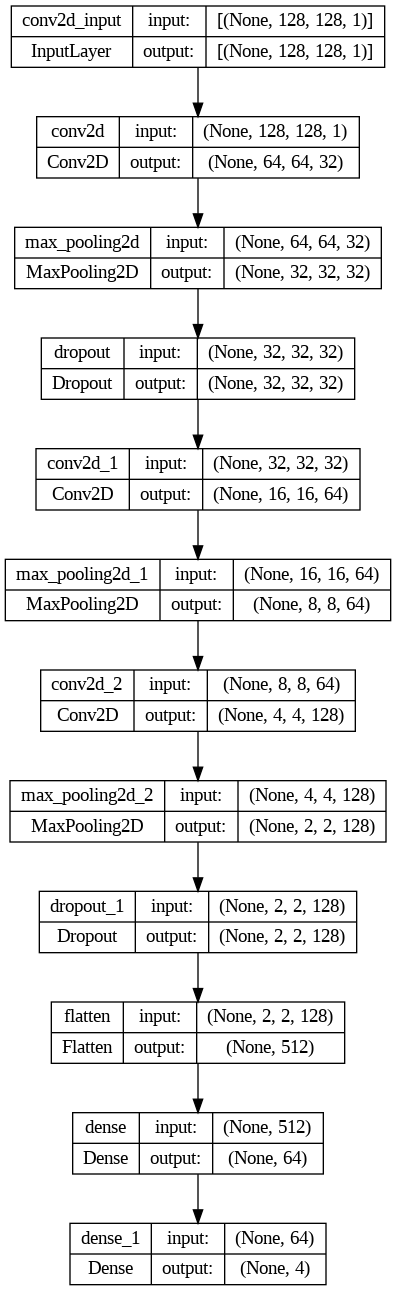

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.utils import plot_model
# Visualizar el modelo
plot_model(modelo, to_file='modelo_cnn.png', show_shapes=True, show_layer_names=True)

# Ahora el modelo se ha guardado como una imagen llamada 'modelo_cnn.png' en el directorio actual


Congelacion de capas

In [ ]:
modelo.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
p.trainable=False

In [ ]:
Epocas=100
p=modelo.fit(
    train_ds,
    epochs=Epocas,
    batch_size=64,
    validation_data=val_ds
)

Epoch 1/100
130/130 [==============================] - 47s 307ms/step - loss: 1.2056 - accuracy: 0.4292 - val_loss: 0.7921 - val_accuracy: 0.6135
Epoch 2/100
130/130 [==============================] - 34s 259ms/step - loss: 0.7264 - accuracy: 0.6554 - val_loss: 0.6349 - val_accuracy: 0.7106
Epoch 3/100
130/130 [==============================] - 35s 267ms/step - loss: 0.6298 - accuracy: 0.7103 - val_loss: 0.5605 - val_accuracy: 0.7365
Epoch 4/100
130/130 [==============================] - 33s 253ms/step - loss: 0.5518 - accuracy: 0.7484 - val_loss: 0.4390 - val_accuracy: 0.8125
Epoch 5/100
130/130 [==============================] - 34s 261ms/step - loss: 0.4673 - accuracy: 0.7948 - val_loss: 0.3598 - val_accuracy: 0.8587
Epoch 6/100
130/130 [==============================] - 34s 259ms/step - loss: 0.3981 - accuracy: 0.8293 - val_loss: 0.3329 - val_accuracy: 0.8625
Epoch 7/100
130/130 [==============================] - 34s 259ms/step - loss: 0.3276 - accuracy: 0.8614 - val_loss: 0.2639 -

In [ ]:
from PIL import Image
import numpy as np

import cv2

def categorizar(ruta):
  img= Image.open(ruta)
  img= img.convert("L")
  img= np.array(img).astype(float)/255
  img=cv2.resize(img,(128,128))
  #Predicción
  prediccion=modelo_cargado.predict(img.reshape(-1,128,128,1))
  return np.argmax(prediccion[0],axis=-1)

In [ ]:
ruta="tampocoalz.jpg"
prediccion=categorizar(ruta)
print(prediccion)

1/1 [==============================] - 0s 31ms/step
2


In [ ]:
ruta="modera.jpg"
prediccion=categorizar(ruta)
print(prediccion)

1/1 [==============================] - 0s 17ms/step
0


In [ ]:
ruta="si.jpg"
prediccion=categorizar(ruta)
print(prediccion)

1/1 [==============================] - 0s 17ms/step
3


In [ ]:
ruta="nope.jpg"
prediccion=categorizar(ruta)
print(prediccion)

1/1 [==============================] - 0s 18ms/step
3


In [ ]:
ruta="non_10.jpg"
prediccion=categorizar(ruta)
print(prediccion)

In [ ]:
ruta="mild.jpg"
prediccion=categorizar(ruta)
print(prediccion)

1/1 [==============================] - 0s 18ms/step
0


In [ ]:
ruta="moderado.jpg"
prediccion=categorizar(ruta)
print(prediccion)

1/1 [==============================] - 0s 36ms/step
1


In [ ]:
ruta="3.jpg"
prediccion=categorizar(ruta)
print(prediccion)

1/1 [==============================] - 0s 39ms/step
3


In [ ]:
ruta="ttt.jpg"
prediccion=categorizar(ruta)
print(prediccion)

1/1 [==============================] - 0s 17ms/step
3


In [ ]:
ruta="mild1.jpg"
prediccion=categorizar(ruta)
print(prediccion)

1/1 [==============================] - 0s 18ms/step
3


In [ ]:
from sklearn.metrics import accuracy_score

ruta="mild.jpg"

prediccion=categorizar(ruta)

exactitud= accuracy_score(val_ds,prediccion)

print(prediccion)
print(exactitud)

NameError: name 'predicciones' is not defined

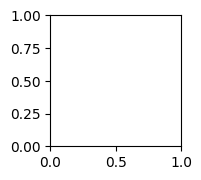

In [ ]:
import numpy as np

for imagenes_prueba, etiquetas_prueba in val_ds.take(0):
  imagenes_prueba = imagenes_prueba.numpy()
  etiquetas_prueba = etiquetas_prueba.numpy()
  predicciones = modelo.predict(imagenes_prueba)

def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
  arr_predicciones, etiqueta_real, img = arr_predicciones[i], etiquetas_reales[i], imagenes[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img[...,0], cmap=plt.cm.binary)

  etiqueta_prediccion = np.argmax(arr_predicciones)
  etiqueta_real = np.argmax(etiquetas_prueba[i])
  if etiqueta_prediccion == etiqueta_real:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(classes_train[etiqueta_prediccion],
                                100*np.max(arr_predicciones),
                                classes_train[etiqueta_real]),
                                color=color)

def graficar_valor_arreglo(i, arr_predicciones, etiqueta_real):
  arr_predicciones, etiqueta_real = arr_predicciones[i], etiqueta_real[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  grafica = plt.bar(range(4), arr_predicciones, color="#777777")
  plt.ylim([0, 1])
  etiqueta_prediccion = np.argmax(arr_predicciones)

  grafica[etiqueta_prediccion].set_color('blue')
  #grafica[etiqueta_real].set_color('blue')

filas = 8
columnas = 8
num_imagenes = filas*columnas
plt.figure(figsize=(2*2*columnas, 2*filas))
for i in range(num_imagenes):
  plt.subplot(filas, 2*columnas, 2*i+1)
  graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)
  plt.subplot(filas, 2*columnas, 2*i+2)
  graficar_valor_arreglo(i, predicciones, etiquetas_prueba)

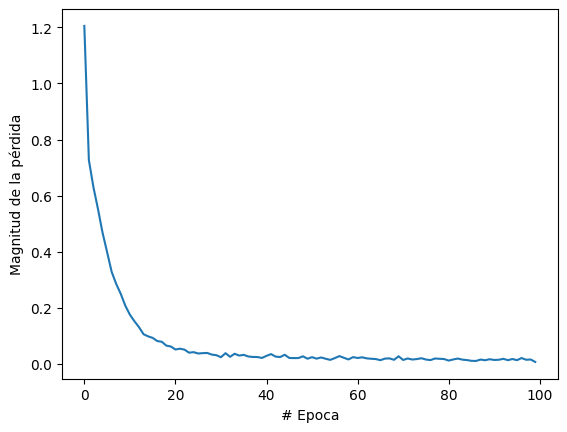

In [ ]:
import matplotlib.pyplot as plt

plt.xlabel("# Epoca")
plt.ylabel("Magnitud de la pérdida")
plt.plot(p.history["loss"])

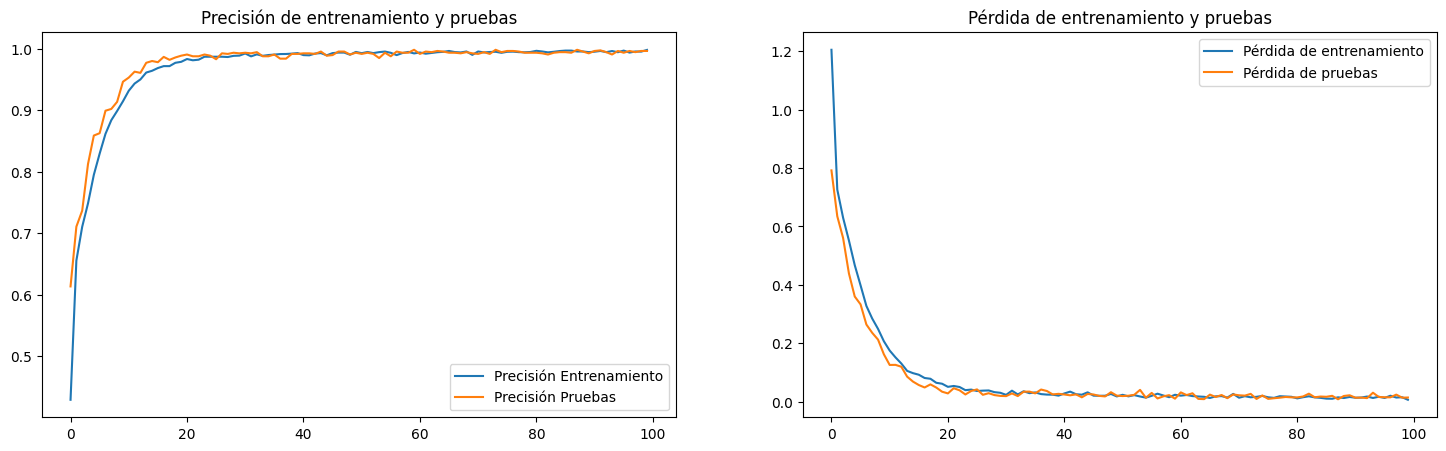

In [ ]:
#Graficas de precisión
acc = p.history['accuracy']
val_acc = p.history['val_accuracy']

loss = p.history['loss']
val_loss = p.history['val_loss']

rango_epocas = range(100)

plt.figure(figsize=(18,5))
plt.subplot(1,2,1)
plt.plot(rango_epocas, acc, label='Precisión Entrenamiento')
plt.plot(rango_epocas, val_acc, label='Precisión Pruebas')
plt.legend(loc='lower right')
plt.title('Precisión de entrenamiento y pruebas')

plt.subplot(1,2,2)
plt.plot(rango_epocas, loss, label='Pérdida de entrenamiento')
plt.plot(rango_epocas, val_loss, label='Pérdida de pruebas')
plt.legend(loc='upper right')
plt.title('Pérdida de entrenamiento y pruebas')
plt.show()

In [ ]:
from PIL import Image
import numpy as np

import cv2

def categorizar(ruta):
  img= Image.open(ruta)
  img= img.convert("RGB")
  img= np.array(img).astype(float)/255

  img=cv2.resize(img,(128,128))
  #Predicción
  prediccion=modelo_cargado.predict(img.reshape(-1,128,128,3))
  return np.argmax(prediccion[0],axis=-1)

In [ ]:
ruta="mild.jpg"
prediccion=categorizar(ruta)
print(prediccion)


1/1 [==============================] - 0s 223ms/step
0


In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Lista de rutas de imágenes de prueba
rutas_imagenes_prueba = ["mild.jpg"]

# Cargar las imágenes de prueba y convertirlas en arrays numpy
X_prueba = ["mild.jpg"]

# Lista de etiquetas correspondientes a las imágenes de prueba
y_prueba = [0, 1, 2, 3]  # Por ejemplo, si las etiquetas son números enteros que representan clases

# Convertir a arrays numpy
X_prueba = np.array(X_prueba)
y_prueba = np.array(y_prueba)

In [ ]:
predicciones = modelo_cargado.predict(test_ds)
predicciones[0]
np.argmax(predicciones[0])

11/11 [==============================] - 2s 156ms/step


0

In [ ]:
loss, acc = modelo.evaluate(prediccion, verbose=2)
print("Restored model, accuracy: {:5.2f}%".format(100 * acc))

NameError: name 'prediccion' is not defined

In [ ]:
from tensorflow.keras.models import load_model

modelo_cargado = load_model("modelo9967.h5")

In [ ]:
modelo.save("modelo9967.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
loss, acc = modelo.evaluate(test_ds, verbose=2)
print("Restored model, Exactitud: {:5.2f}%".format(100 * acc))

17/17 - 2s - loss: 0.0774 - accuracy: 0.9894 - 2s/epoch - 122ms/step
Restored model, Exactitud: 98.94%


In [ ]:
loss, acc = modelo.evaluate(val_ds, verbose=2)
print("Exactitud del modelo: {:5.2f}%".format(100 * acc))

17/17 - 3s - loss: 0.0136 - accuracy: 0.9962 - 3s/epoch - 201ms/step
Exactitud del modelo: 99.62%


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = modelo.predict(images)
    y_true.extend(np.argmax(labels, axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))


conf_matrix = confusion_matrix(y_true, y_pred)

print("Matriz de Confusión:")
print(conf_matrix)

1/1 [==============================] - 0s 159ms/step
Matriz de Confusión:
[[260   0   0   0]
 [  0 260   0   0]
 [  0   0 257   3]
 [  0   0   1 259]]


1/1 [==============================] - 0s 29ms/step


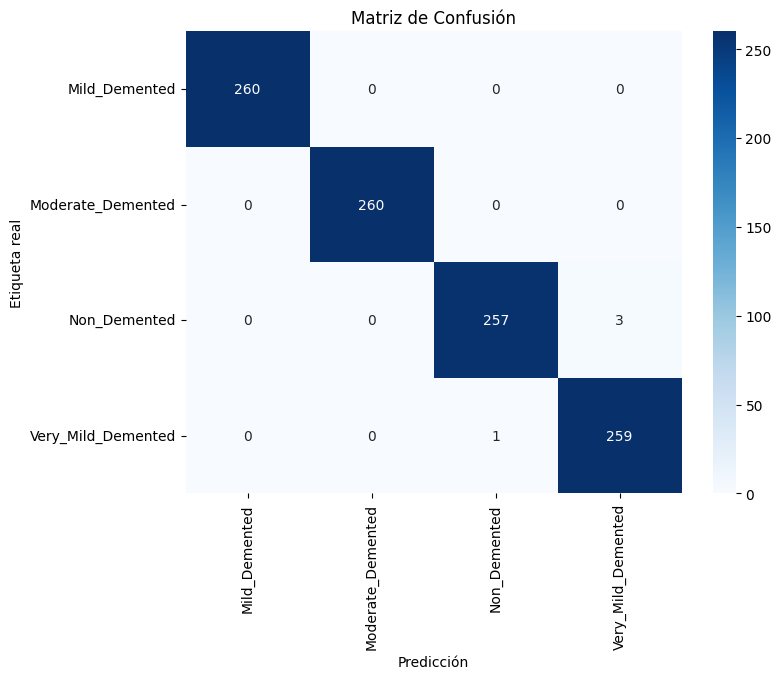

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = modelo.predict(images)
    y_true.extend(np.argmax(labels, axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))


conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes_train, yticklabels=classes_train)
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.title('Matriz de Confusión')
plt.show()

In [ ]:
import sklearn.metrics

sklearn.metrics.accuracy_score(y_true,y_pred)

0.9961538461538462

In [ ]:
from sklearn.metrics import precision_score
precision_score(y_true, y_pred, average='macro')


0.9961684123320906

In [ ]:
sklearn.metrics.recall_score(y_true,y_pred, average='macro')

0.9961538461538462

In [ ]:
y_pred = modelo_cargado.predict(val_ds)

y_prob = y_pred
print(y_prob)

10/10 [==============================] - 1s 76ms/step
[[1.9266340e-12 1.1916916e-13 9.9999982e-01 8.1239754e-08]
 [4.2760945e-10 2.6886299e-10 9.9995452e-01 4.5382025e-05]
 [1.2078207e-12 4.3424028e-11 9.9999243e-01 7.5605885e-06]
 ...
 [2.3711391e-05 1.1422606e-09 1.7501646e-09 9.9997628e-01]
 [2.3564772e-12 5.0837443e-13 9.9999988e-01 7.7236450e-08]
 [3.7183991e-08 4.3098614e-10 1.6097320e-09 1.0000000e+00]]


In [ ]:
import tensorflow as tf
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelBinarizer


# Suponiendo que y_true contiene las verdaderas etiquetas de tus datos de validación
# y_true debe tener la forma (n_samples, n_classes)
# Asegúrate de haber cargado correctamente tu modelo y tus datos de validación

# Obtener las probabilidades predichas por el modelo para los datos de validación
y_prob = modelo_cargado.predict(val_ds)

# Convertir y_true a una matriz binaria
lb = LabelBinarizer()
y_true_bin = lb.fit_transform(y_true)

# Asegurar que y_prob tenga la misma longitud que y_true_bin
if len(y_prob) < len(y_true_bin):
    diff = len(y_true_bin) - len(y_prob)
    y_prob = np.concatenate((y_prob, np.zeros((diff, y_prob.shape[1]))), axis=0)

# Calcular el FPR y TPR para cada clase individualmente
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(lb.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcular el promedio de todas las tasas de FPR y TPR para dibujar la línea base
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(lb.classes_))]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(lb.classes_)):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= len(lb.classes_)

# Calcular el AUC macro promediando los AUC de cada clase
auc_macro = sum(roc_auc.values()) / len(roc_auc)

# Dibujar la curva ROC para cada clase
plt.figure(figsize=(8, 6))
for i in range(len(lb.classes_)):
    plt.plot(fpr[i], tpr[i], label='ROC curve (area = %0.2f) for class %s' % (roc_auc[i], lb.classes_[i]))

# Dibujar la línea base
plt.plot(all_fpr, mean_tpr, 'k--', label='Mean ROC (area = %0.2f)' % auc_macro)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [ ]:
print("Shape de y_true_bin:", y_true_bin.shape)
print("Shape de y_prob:", y_prob.shape)

#Verificar la longitud de y_true_bin y y_prob
print("Longitud de y_true_bin:", len(y_true_bin))
print("Longitud de y_prob:", len(y_prob))

y_prob = y_prob[:len(y_true_bin)]

#Verificar la longitud de y_prob después de la corrección
print("Longitud de y_prob después de la corrección:", len(y_prob))

In [ ]:
from sklearn.metrics import classification_report

#y_true contiene las etiquetas verdaderas, y_pred contiene las etiquetas predichas
#Suponiendo que son arrays de numpy
report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       260
           1       1.00      1.00      1.00       260
           2       1.00      0.99      0.99       260
           3       0.99      1.00      0.99       260

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



In [ ]:
y_prob = modelo.predict(val_ds)

17/17 [==============================] - 2s 94ms/step


1/1 [==============================] - 0s 55ms/step
1.0
1.0
0.9998915187376726
0.9998816568047337


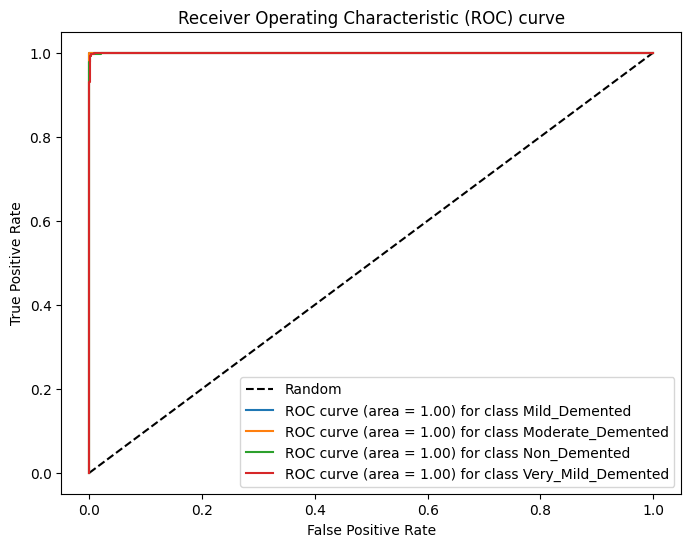

In [ ]:
from sklearn.metrics import roc_curve, auc

# Obtener las etiquetas verdaderas y las probabilidades predichas
y_true = []
y_prob = []
for images, labels in val_ds:
    predictions = modelo.predict(images)
    y_true.extend(labels.numpy())  # Convertir las etiquetas a una lista de numpy
    y_prob.extend(predictions)  # Extender la lista de probabilidades predichas

y_true = np.array(y_true)  # Convertir a un array numpy
y_prob = np.array(y_prob)  # Convertir a un array numpy

# Calcular la curva ROC para cada clase usando One-vs-Rest (OvR)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(classes_train)):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Graficar las curvas ROC para cada clase
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Random')

for i in range(len(classes_train)):
    plt.plot(fpr[i], tpr[i], label='ROC curve (area = {:.2f}) for class {}'.format(roc_auc[i], classes_train[i]))
    print(roc_auc[i])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) curve')
plt.legend(loc='lower right')
plt.show()